# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [4]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [5]:
# Q3(a): Report the median and standard deviation for columns with missing values
missing_cols = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values: {missing_cols}\n")

print("=== Q3(a): Before Imputation ===")
for col in missing_cols:
    med = df[col].median()
    std = df[col].std()
    n_missing = df[col].isnull().sum()
    print(f"{col}: median={med:.4f}, std={std:.4f}, missing_count={n_missing}")

Columns with missing values: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'BranchLength']

=== Q3(a): Before Imputation ===
SepalLengthCm: median=6.3000, std=1.0371, missing_count=28
SepalWidthCm: median=2.9000, std=0.3896, missing_count=57
PetalLengthCm: median=5.0856, std=1.5828, missing_count=150
PetalWidthCm: median=1.6000, std=0.7067, missing_count=22
BranchLength: median=16.3000, std=1.0352, missing_count=24


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using "Nearest Neighbors Imputation"
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [6]:
# Q3(b): Report the median and standard deviation after KNN Imputation
print("=== Q3(b): After KNN Imputation ===")
for col in missing_cols:
    med = df[col].median()
    std = df[col].std()
    n_missing = df[col].isnull().sum()
    print(f"{col}: median={med:.4f}, std={std:.4f}, missing_count={n_missing}")

print("\n=== Comparison (Before vs After) ===")
print(f"{'Column':<20} {'Median (Before)':>16} {'Median (After)':>16} {'Std (Before)':>14} {'Std (After)':>14}")
print("-" * 84)
# Re-read original data for comparison
df_orig = pd.read_csv('data/NYCU_Iris.csv')
for col in missing_cols:
    df_orig[col] = pd.to_numeric(df_orig[col], errors='coerce')
    med_before = df_orig[col].median()
    std_before = df_orig[col].std()
    med_after = df[col].median()
    std_after = df[col].std()
    print(f"{col:<20} {med_before:>16.4f} {med_after:>16.4f} {std_before:>14.4f} {std_after:>14.4f}")

=== Q3(b): After KNN Imputation ===
SepalLengthCm: median=6.3000, std=1.0093, missing_count=0
SepalWidthCm: median=2.9000, std=0.3724, missing_count=0
PetalLengthCm: median=5.0357, std=1.5150, missing_count=0
PetalWidthCm: median=1.7000, std=0.6946, missing_count=0
BranchLength: median=16.3000, std=1.0110, missing_count=0

=== Comparison (Before vs After) ===
Column                Median (Before)   Median (After)   Std (Before)    Std (After)
------------------------------------------------------------------------------------
SepalLengthCm                  6.3000           6.3000         1.0371         1.0093
SepalWidthCm                   2.9000           2.9000         0.3896         0.3724
PetalLengthCm                  5.0856           5.0357         1.5828         1.5150
PetalWidthCm                   1.6000           1.7000         0.7067         0.6946
BranchLength                  16.3000          16.3000         1.0352         1.0110


In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

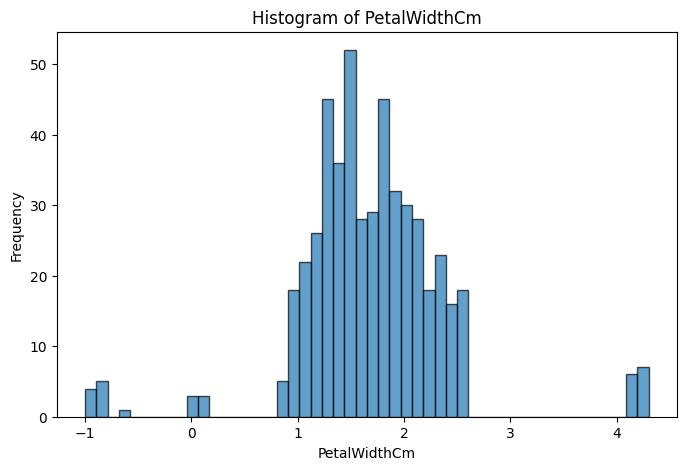

=== Q4(b): Largest Positive Correlation with PetalWidthCm ===
PetalWidthCompactness: r = 0.9917

=== Q4(c): Top 5 Strongest Negative Correlations with PetalWidthCm ===
SepalWidthMajorAxis: r = -0.0964
SepalGlossIndex: r = -0.0952
SepalWidthCompactness: r = -0.0885
SepalWidthCurvature: r = -0.0813
SepalWidthMinorAxis: r = -0.0744

=== Q4(d): Boxplot features ===
['PetalWidthCompactness', 'SepalWidthMajorAxis', 'SepalGlossIndex', 'SepalWidthCompactness', 'SepalWidthCurvature', 'SepalWidthMinorAxis']


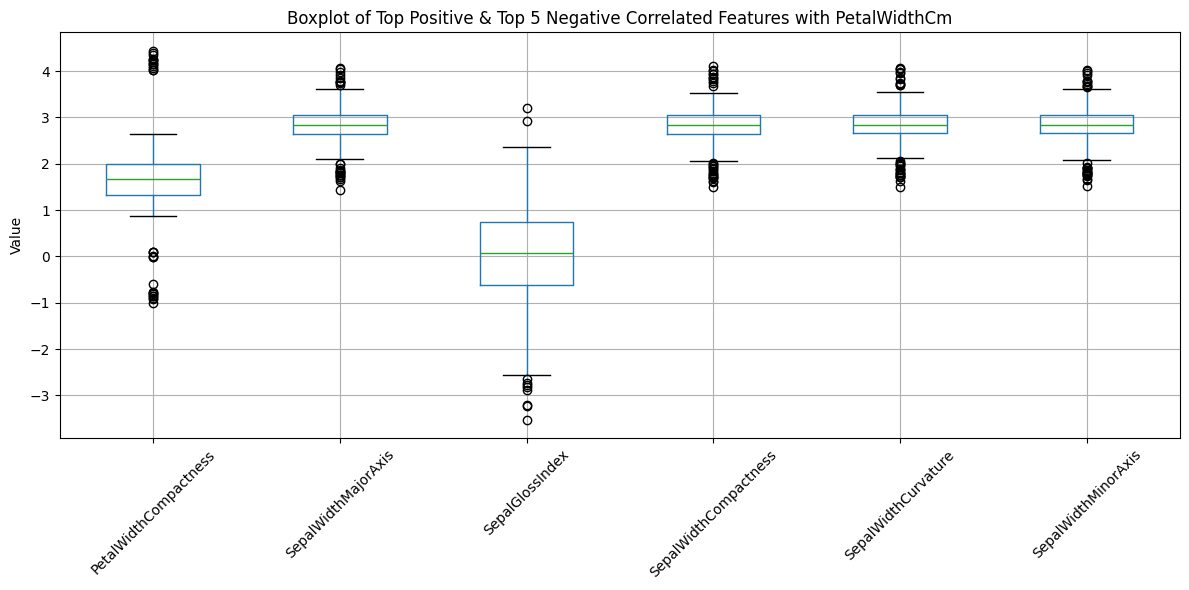

In [8]:
import os
from sklearn.feature_selection import r_regression

os.makedirs('Chart', exist_ok=True)

# ============================================================
# Q4(a): Plot the histogram of PetalWidthCm
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['PetalWidthCm'], bins=50, edgecolor='black', alpha=0.7)
ax.set_title('Histogram of PetalWidthCm')
ax.set_xlabel('PetalWidthCm')
ax.set_ylabel('Frequency')
fig.savefig('Chart/Q4a_PetalWidthCm_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Q4(b): Feature with largest positive Pearson correlation
# ============================================================
exclude_cols = ['PetalWidthCm', 'Species', 'Id']
corr_features = [c for c in df.columns if c not in exclude_cols]

X_corr = df[corr_features].values
y_corr = df['PetalWidthCm'].values

# r_regression returns Pearson correlation for each feature vs target
correlations = r_regression(X_corr, y_corr)
corr_series = pd.Series(correlations, index=corr_features)

# Largest positive correlation
top_positive = corr_series.idxmax()
print(f"=== Q4(b): Largest Positive Correlation with PetalWidthCm ===")
print(f"{top_positive}: r = {corr_series[top_positive]:.4f}")

# ============================================================
# Q4(c): Top 5 features with strongest negative correlations
# ============================================================
top5_negative = corr_series.nsmallest(5)
print(f"\n=== Q4(c): Top 5 Strongest Negative Correlations with PetalWidthCm ===")
for feat, r_val in top5_negative.items():
    print(f"{feat}: r = {r_val:.4f}")

# ============================================================
# Q4(d): Boxplot for all features from 4(b) and 4(c)
# ============================================================
boxplot_features = [top_positive] + top5_negative.index.tolist()
print(f"\n=== Q4(d): Boxplot features ===")
print(boxplot_features)

fig, ax = plt.subplots(figsize=(12, 6))
df[boxplot_features].boxplot(ax=ax, rot=45)
ax.set_title('Boxplot of Top Positive & Top 5 Negative Correlated Features with PetalWidthCm')
ax.set_ylabel('Value')
plt.tight_layout()
fig.savefig('Chart/Q4d_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Training

### Prepare the data

In [8]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!


Setting: No Regularization
50. Training loss: 0.6572950512169217, Val loss:0.6699856821878871
100. Training loss: 0.6226307711490021, Val loss:0.6436636316717124
150. Training loss: 0.5968536106438317, Val loss:0.6248019734101419
200. Training loss: 0.5770724410855091, Val loss:0.6109725987973054
250. Training loss: 0.5614500987624708, Val loss:0.6006341363275265
300. Training loss: 0.5488013196405573, Val loss:0.5927862551965061
350. Training loss: 0.5383413721955611, Val loss:0.5867610521735693
400. Training loss: 0.5295356518896498, Val loss:0.5820996162672264
450. Training loss: 0.5220096572557988, Val loss:0.5784781297261021
500. Training loss: 0.51549415543084, Val loss:0.5756625817533594
550. Training loss: 0.5097909798441069, Val loss:0.5734802622069771
600. Training loss: 0.5047511496548615, Val loss:0.5718013280805994
650. Training loss: 0.5002605183372977, Val loss:0.5705265741611238
700. Training loss: 0.49623013467643184, Val loss:0.5695791245134203
750. Training loss: 0.

6600. Training loss: 0.42752984915074427, Val loss:0.6216156920654735
6650. Training loss: 0.42742608125660825, Val loss:0.621966429109526
6700. Training loss: 0.42732345889109086, Val loss:0.6223151675168737
6750. Training loss: 0.42722195623951426, Val loss:0.6226619229409281
6800. Training loss: 0.4271215482290502, Val loss:0.6230067108416623
6850. Training loss: 0.42702221050317124, Val loss:0.6233495464889192
6900. Training loss: 0.42692391939713487, Val loss:0.6236904449656712
6950. Training loss: 0.42682665191445235, Val loss:0.6240294211712221
7000. Training loss: 0.4267303857042964, Val loss:0.6243664898243578
7050. Training loss: 0.42663509903980484, Val loss:0.6247016654664457
7100. Training loss: 0.4265407707972382, Val loss:0.6250349624644785
7150. Training loss: 0.42644738043595287, Val loss:0.625366395014071
7200. Training loss: 0.426354907979154, Val loss:0.6256959771424009
7250. Training loss: 0.42626333399538985, Val loss:0.626023722711102
7300. Training loss: 0.42617

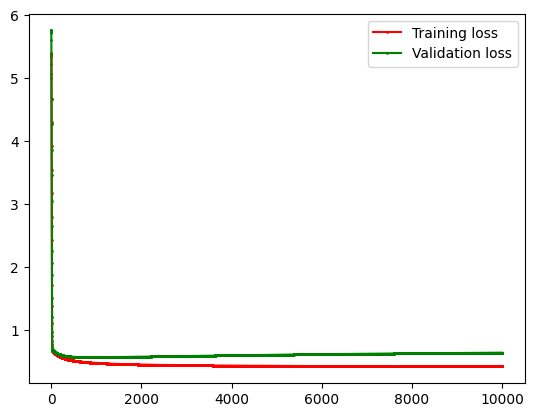

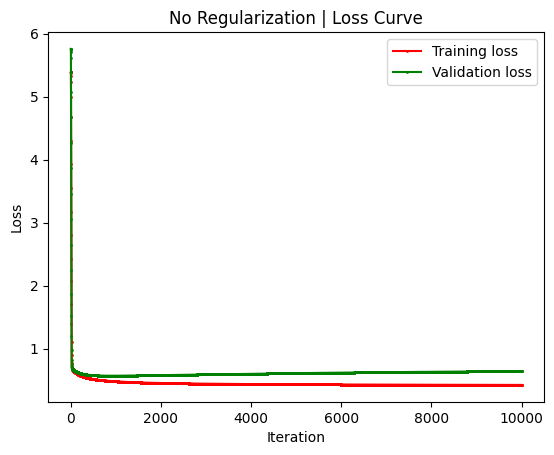

Sum of absolute values of weights: 62.1932
No Regularization
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


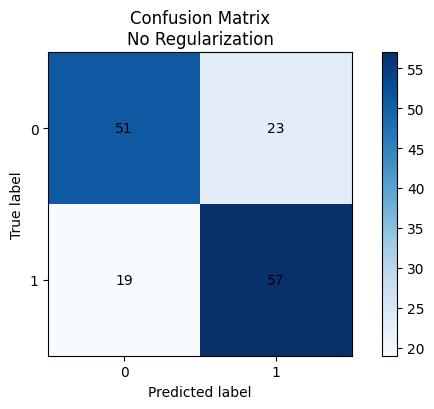



Setting: L2 (reg_lambda=0.01)
50. Training loss: 0.6572929744907086, Val loss:0.6699828194400217
100. Training loss: 0.622637070859397, Val loss:0.6436662386803188
150. Training loss: 0.5968724567755489, Val loss:0.6248125819822072
200. Training loss: 0.5771051326187799, Val loss:0.6109911766151703
250. Training loss: 0.5614967431436563, Val loss:0.6006595362014496
300. Training loss: 0.5488615550371709, Val loss:0.592816880200311
350. Training loss: 0.5384146721109383, Val loss:0.5867951648523863
400. Training loss: 0.5296214516465223, Val loss:0.5821354839154358
450. Training loss: 0.5221074045422048, Val loss:0.5785140918733357
500. Training loss: 0.5156033285344711, Val loss:0.575697079625259
550. Training loss: 0.5099110923718569, Val loss:0.5735118491814875
600. Training loss: 0.5048817498726621, Val loss:0.5718286705532784
650. Training loss: 0.5004011866212237, Val loss:0.5705484476177356
700. Training loss: 0.4963804805267807, Val loss:0.5695944073134431
750. Training loss: 

3250. Training loss: 0.44018294338391967, Val loss:0.5916842579417178
3300. Training loss: 0.4398536134090591, Val loss:0.5921968374845455
3350. Training loss: 0.43953276906488337, Val loss:0.5927057632351963
3400. Training loss: 0.43922007288161263, Val loss:0.5932110562509915
3450. Training loss: 0.43891520477353124, Val loss:0.5937127394441147
3500. Training loss: 0.43861786093072563, Val loss:0.5942108372918663
3550. Training loss: 0.4383277527953642, Val loss:0.5947053755833329
3600. Training loss: 0.43804460611500345, Val loss:0.5951963811979623
3650. Training loss: 0.437768160066166, Val loss:0.5956838819120982
3700. Training loss: 0.4374981664421149, Val loss:0.5961679062300298
3750. Training loss: 0.4372343888993474, Val loss:0.5966484832365396
3800. Training loss: 0.4369766022578635, Val loss:0.5971256424683051
3850. Training loss: 0.4367245918507429, Val loss:0.5975994138018449
3900. Training loss: 0.43647815291898606, Val loss:0.5980698273559759
3950. Training loss: 0.43623

6700. Training loss: 0.4278700138545045, Val loss:0.6199058327974729
6750. Training loss: 0.4277702599444167, Val loss:0.6202282323770065
6800. Training loss: 0.4276716018053926, Val loss:0.6205486391419335
6850. Training loss: 0.4275740153168026, Val loss:0.6208670690978443
6900. Training loss: 0.4274774770442299, Val loss:0.621183538057439
6950. Training loss: 0.4273819642160573, Val loss:0.6214980616437391
7000. Training loss: 0.42728745470098844, Val loss:0.621810655293252
7050. Training loss: 0.4271939269864635, Val loss:0.6221213342590849
7100. Training loss: 0.42710136015792516, Val loss:0.6224301136140088
7150. Training loss: 0.42700973387889846, Val loss:0.6227370082534729
7200. Training loss: 0.4269190283718453, Val loss:0.6230420328985683
7250. Training loss: 0.4268292243997622, Val loss:0.6233452020989466
7300. Training loss: 0.4267403032484836, Val loss:0.623646530235684
7350. Training loss: 0.42665224670966406, Val loss:0.6239460315241043
7400. Training loss: 0.4265650370

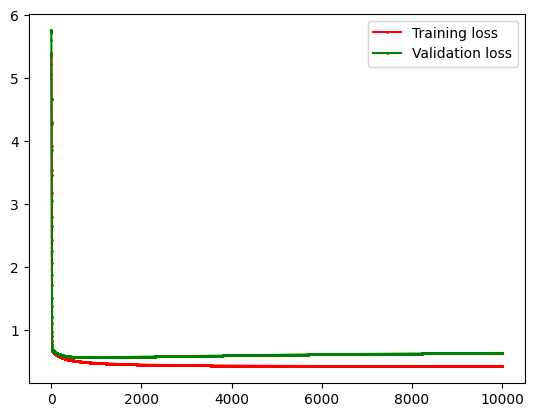

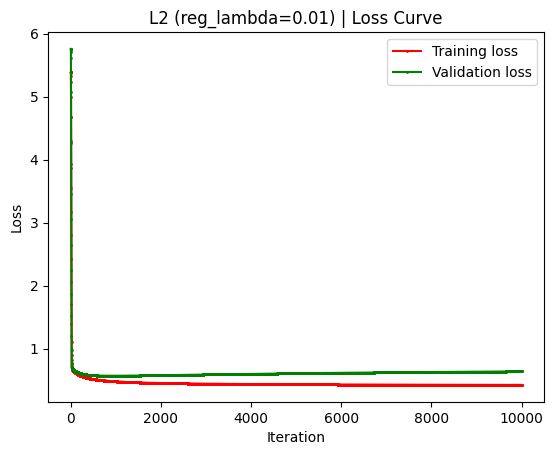

Sum of absolute values of weights: 60.6596
L2 (reg_lambda=0.01)
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


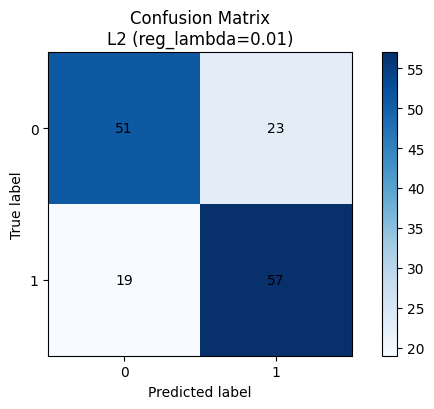



Setting: L2 (reg_lambda=1)
50. Training loss: 0.6571098767748111, Val loss:0.6697244267768969
100. Training loss: 0.6233246012236595, Val loss:0.643999865252734
150. Training loss: 0.5988483414837363, Val loss:0.6260046211970154
200. Training loss: 0.580503081098561, Val loss:0.6130584747744167
250. Training loss: 0.5663340514385814, Val loss:0.6035153895899893
300. Training loss: 0.555109610778399, Val loss:0.5963362172188005
350. Training loss: 0.5460282664733441, Val loss:0.5908438177965458
400. Training loss: 0.5385508819400877, Val loss:0.5865832541498985
450. Training loss: 0.5323033478328499, Val loss:0.5832403037115937
500. Training loss: 0.5270186638253865, Val loss:0.5805925757006578
550. Training loss: 0.5225014437416007, Val loss:0.5784792861358807
600. Training loss: 0.5186055098416564, Val loss:0.5767820163311911
650. Training loss: 0.5152193449448941, Val loss:0.5754121279039557
700. Training loss: 0.5122563954812427, Val loss:0.5743023265172252
750. Training loss: 0.5

3150. Training loss: 0.4846987160687304, Val loss:0.5711547306831057
3200. Training loss: 0.4846467961279649, Val loss:0.571184794590237
3250. Training loss: 0.4845979857009425, Val loss:0.571213852727872
3300. Training loss: 0.48455208344738027, Val loss:0.5712419263946643
3350. Training loss: 0.48450890230629334, Val loss:0.5712690379631203
3400. Training loss: 0.4844682683768935, Val loss:0.5712952106315572
3450. Training loss: 0.48443001989661016, Val loss:0.5713204682087644
3500. Training loss: 0.4843940063069294, Val loss:0.5713448349274083
3550. Training loss: 0.4843600873987308, Val loss:0.5713683352827055
3600. Training loss: 0.48432813252966317, Val loss:0.5713909938933166
3650. Training loss: 0.48429801990686955, Val loss:0.5714128353817746
3700. Training loss: 0.4842696359290495, Val loss:0.5714338842720862
3750. Training loss: 0.48424287458245974, Val loss:0.5714541649024308
3800. Training loss: 0.4842176368859822, Val loss:0.5714737013511227
3850. Training loss: 0.4841938

5950. Training loss: 0.48382061660386333, Val loss:0.5718741929388874
6000. Training loss: 0.48381833585475026, Val loss:0.571877640146867
6050. Training loss: 0.4838161698846211, Val loss:0.5718809511860294
6100. Training loss: 0.48381411269832386, Val loss:0.571884131384448
6150. Training loss: 0.4838121586263566, Val loss:0.5718871858657675
6200. Training loss: 0.4838103023063958, Val loss:0.5718901195567208
6250. Training loss: 0.48380853866592405, Val loss:0.5718929371943963
6300. Training loss: 0.483806862905892, Val loss:0.5718956433332654
6350. Training loss: 0.48380527048534594, Val loss:0.5718982423519715
6400. Training loss: 0.4838037571069623, Val loss:0.5719007384598894
6450. Training loss: 0.4838023187034326, Val loss:0.5719031357034606
6500. Training loss: 0.4838009514246437, Val loss:0.5719054379723071
6550. Training loss: 0.4837996516256082, Val loss:0.571907649005133
6600. Training loss: 0.48379841585509525, Val loss:0.5719097723954198
6650. Training loss: 0.483797240

9350. Training loss: 0.48377554981264004, Val loss:0.5719555807355938
9400. Training loss: 0.48377546574715635, Val loss:0.5719557998926852
9450. Training loss: 0.4837753854355451, Val loss:0.5719560103491959
9500. Training loss: 0.48377530870440943, Val loss:0.5719562124517482
9550. Training loss: 0.4837752353886324, Val loss:0.5719564065331463
9600. Training loss: 0.4837751653309677, Val loss:0.5719565929129242
9650. Training loss: 0.48377509838165245, Val loss:0.5719567718978745
9700. Training loss: 0.48377503439803987, Val loss:0.5719569437825552
9750. Training loss: 0.48377497324424995, Val loss:0.5719571088497764
9800. Training loss: 0.4837749147908378, Val loss:0.5719572673710679
9850. Training loss: 0.48377485891447947, Val loss:0.5719574196071275
9900. Training loss: 0.48377480549767266, Val loss:0.5719575658082542
9950. Training loss: 0.4837747544284534, Val loss:0.5719577062147608
10000. Training loss: 0.48377470560012614, Val loss:0.5719578410573714


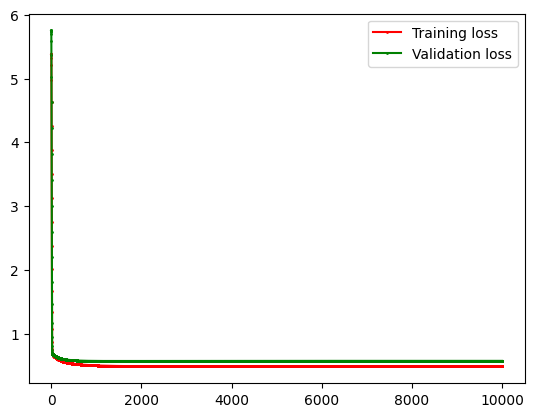

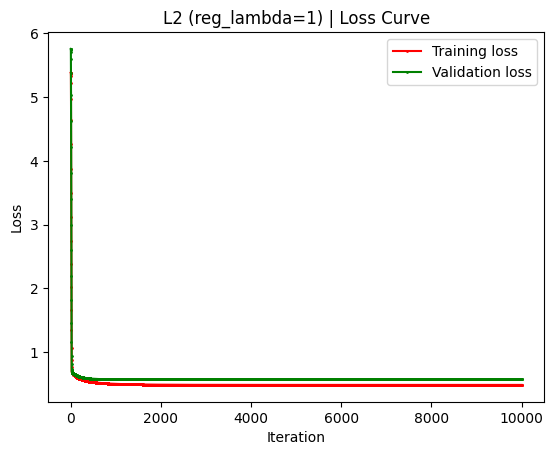

Sum of absolute values of weights: 24.6869
L2 (reg_lambda=1)
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


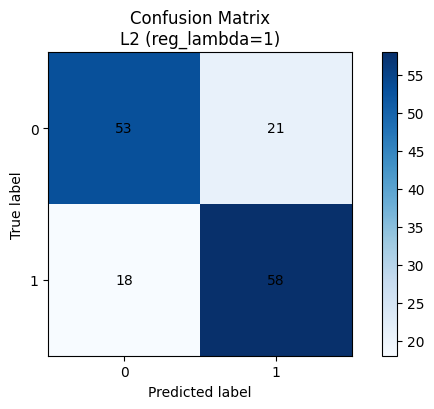



Setting: L2 (reg_lambda=100)
50. Training loss: 0.6750694290943433, Val loss:0.6840309642470094
100. Training loss: 0.6747548127534179, Val loss:0.6839309748933531
150. Training loss: 0.6747488372001222, Val loss:0.6839298599003173
200. Training loss: 0.6747487203171995, Val loss:0.6839298551190556
250. Training loss: 0.6747487180286232, Val loss:0.6839298554515596
300. Training loss: 0.6747487179838312, Val loss:0.6839298554687433
350. Training loss: 0.6747487179829557, Val loss:0.6839298554693461
400. Training loss: 0.6747487179829386, Val loss:0.6839298554693646
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss:

3500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3750. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3800. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3850. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3900. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3950. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
4000. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
4050. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
4100. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
4150. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
4200. Training loss: 0.67474871798

9150. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9200. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9250. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9300. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9350. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9400. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9450. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9750. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9800. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
9850. Training loss: 0.67474871798

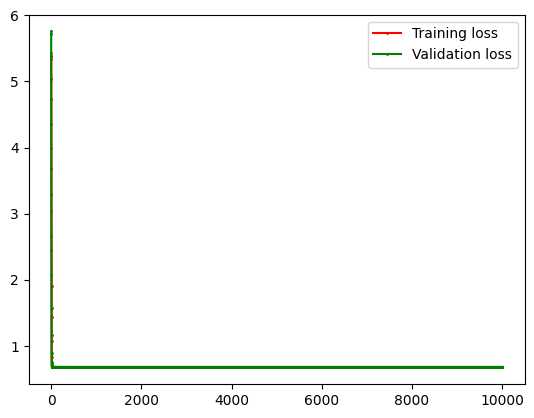

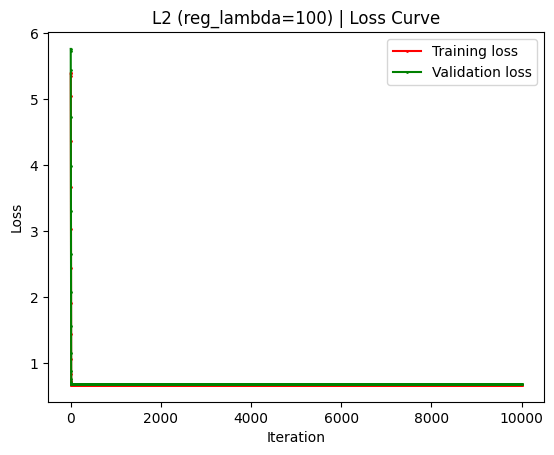

Sum of absolute values of weights: 0.9552
L2 (reg_lambda=100)
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


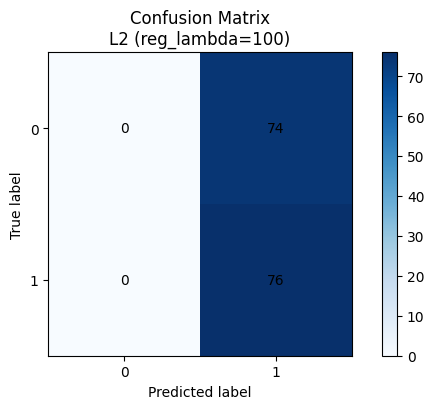

In [10]:
# Q5: Regularization Comparison
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Settings: (label, reg_type, reg_lambda)
settings = [
    ('No Regularization', '', 0.0),
    ('L2 (reg_lambda=0.01)', 'l2', 0.01),
    ('L2 (reg_lambda=1)', 'l2', 1.0),
    ('L2 (reg_lambda=100)', 'l2', 100.0),
]

for label, reg_type, reg_lambda in settings:
    print(f"\n{'='*60}")
    print(f"Setting: {label}")
    print(f"{'='*60}")

    np.random.seed(seed)
    model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
    model.fit(X_train, y_train, lr=0.1, n_iteration=10000, val_ratio=0.2, reg_type=reg_type, reg_lambda=reg_lambda)
    plt.close('all')  # close the untitled inline loss plot from model.fit

    # Re-plot loss curve with title and save
    fig, ax = plt.subplots()
    ax.set_title(f'{label} | Loss Curve')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.plot(range(len(model.train_losses)), model.train_losses, 'o-', color='r', label='Training loss', markersize=1)
    ax.plot(range(len(model.val_losses)), model.val_losses, 'o-', color='g', label='Validation loss', markersize=1)
    ax.legend(loc='best')
    save_name = label.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '')
    fig.savefig(f'Chart/Q5_{save_name}_loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print model weight info
    print(f"Sum of absolute values of weights: {np.sum(np.abs(model.W)):.4f}")

    # Evaluation on test set
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(
        y_test, y_pred,
        title=f'{label}',
        save_path=f'Chart/Q5_{save_name}_confusion_matrix.png'
    )
    print()

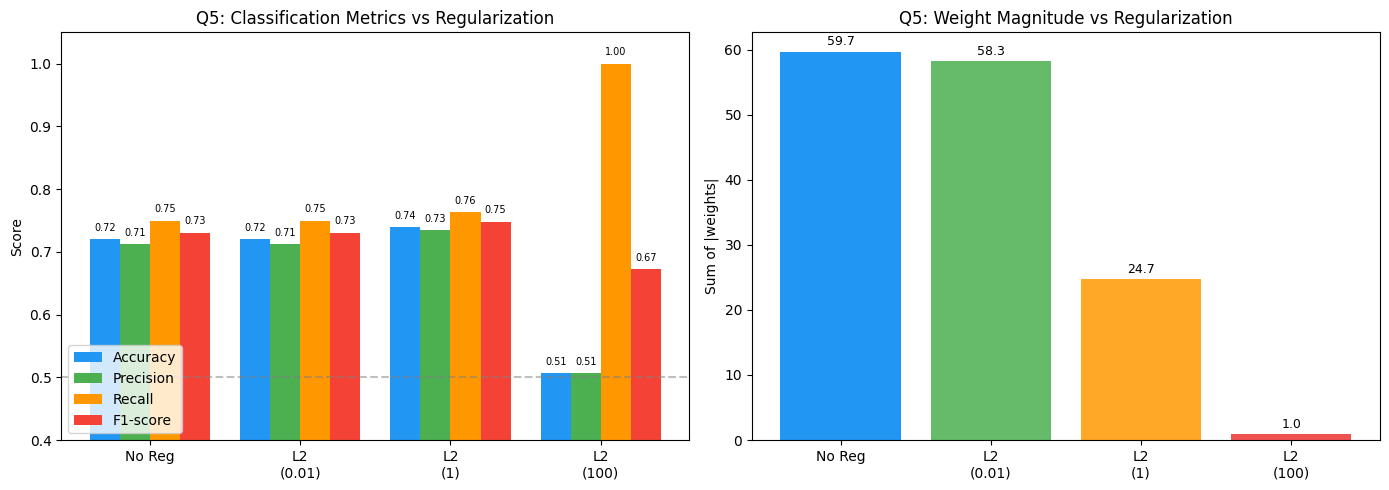

In [11]:
# Q5: Visual Comparison of Regularization Results
import matplotlib.pyplot as plt
import numpy as np

labels = ['No Reg', 'L2\n(0.01)', 'L2\n(1)', 'L2\n(100)']
accuracy  = [0.7200, 0.7200, 0.7400, 0.5067]
precision = [0.7125, 0.7125, 0.7342, 0.5067]
recall    = [0.7500, 0.7500, 0.7632, 1.0000]
f1        = [0.7308, 0.7308, 0.7484, 0.6726]
weight_sum = [59.6665, 58.2757, 24.6866, 0.9552]

x = np.arange(len(labels))
width = 0.2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Metrics comparison
bars1 = ax1.bar(x - 1.5*width, accuracy,  width, label='Accuracy',  color='#2196F3')
bars2 = ax1.bar(x - 0.5*width, precision, width, label='Precision', color='#4CAF50')
bars3 = ax1.bar(x + 0.5*width, recall,    width, label='Recall',    color='#FF9800')
bars4 = ax1.bar(x + 1.5*width, f1,        width, label='F1-score',  color='#F44336')

ax1.set_ylabel('Score')
ax1.set_title('Q5: Classification Metrics vs Regularization')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0.4, 1.05)
ax1.legend(loc='lower left')
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7)

# Right: Weight magnitude
ax2.bar(x, weight_sum, color=['#2196F3', '#66BB6A', '#FFA726', '#EF5350'])
ax2.set_ylabel('Sum of |weights|')
ax2.set_title('Q5: Weight Magnitude vs Regularization')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
for i, v in enumerate(weight_sum):
    ax2.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig('Chart/Q5_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

50. Training loss: 0.6572950512169217, Val loss:0.6699856821878871
100. Training loss: 0.6226307711490021, Val loss:0.6436636316717124
150. Training loss: 0.5968536106438317, Val loss:0.6248019734101419
200. Training loss: 0.5770724410855091, Val loss:0.6109725987973054
250. Training loss: 0.5614500987624708, Val loss:0.6006341363275265
300. Training loss: 0.5488013196405573, Val loss:0.5927862551965061
350. Training loss: 0.5383413721955611, Val loss:0.5867610521735693
400. Training loss: 0.5295356518896498, Val loss:0.5820996162672264
450. Training loss: 0.5220096572557988, Val loss:0.5784781297261021
500. Training loss: 0.51549415543084, Val loss:0.5756625817533594
550. Training loss: 0.5097909798441069, Val loss:0.5734802622069771
600. Training loss: 0.5047511496548615, Val loss:0.5718013280805994
650. Training loss: 0.5002605183372977, Val loss:0.5705265741611238
700. Training loss: 0.49623013467643184, Val loss:0.5695791245134203
750. Training loss: 0.49258962365573294, Val loss:

6650. Training loss: 0.42742608125660825, Val loss:0.621966429109526
6700. Training loss: 0.42732345889109086, Val loss:0.6223151675168737
6750. Training loss: 0.42722195623951426, Val loss:0.6226619229409281
6800. Training loss: 0.4271215482290502, Val loss:0.6230067108416623
6850. Training loss: 0.42702221050317124, Val loss:0.6233495464889192
6900. Training loss: 0.42692391939713487, Val loss:0.6236904449656712
6950. Training loss: 0.42682665191445235, Val loss:0.6240294211712221
7000. Training loss: 0.4267303857042964, Val loss:0.6243664898243578
7050. Training loss: 0.42663509903980484, Val loss:0.6247016654664457
7100. Training loss: 0.4265407707972382, Val loss:0.6250349624644785
7150. Training loss: 0.42644738043595287, Val loss:0.625366395014071
7200. Training loss: 0.426354907979154, Val loss:0.6256959771424009
7250. Training loss: 0.42626333399538985, Val loss:0.626023722711102
7300. Training loss: 0.4261726395807584, Val loss:0.6263496454191068
7350. Training loss: 0.426082

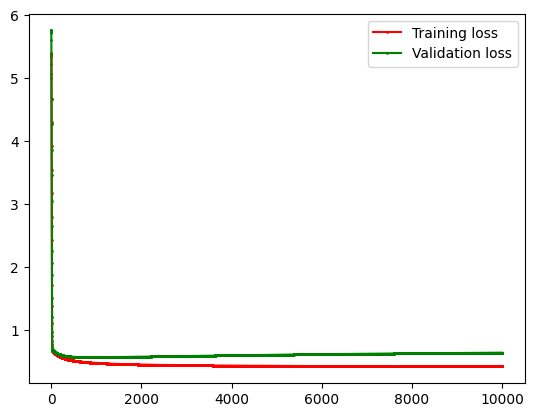

50. Training loss: 0.6572929744907086, Val loss:0.6699828194400217
100. Training loss: 0.622637070859397, Val loss:0.6436662386803188
150. Training loss: 0.5968724567755489, Val loss:0.6248125819822072
200. Training loss: 0.5771051326187799, Val loss:0.6109911766151703
250. Training loss: 0.5614967431436563, Val loss:0.6006595362014496
300. Training loss: 0.5488615550371709, Val loss:0.592816880200311
350. Training loss: 0.5384146721109383, Val loss:0.5867951648523863
400. Training loss: 0.5296214516465223, Val loss:0.5821354839154358
450. Training loss: 0.5221074045422048, Val loss:0.5785140918733357
500. Training loss: 0.5156033285344711, Val loss:0.575697079625259
550. Training loss: 0.5099110923718569, Val loss:0.5735118491814875
600. Training loss: 0.5048817498726621, Val loss:0.5718286705532784
650. Training loss: 0.5004011866212237, Val loss:0.5705484476177356
700. Training loss: 0.4963804805267807, Val loss:0.5695944073134431
750. Training loss: 0.4927492828335417, Val loss:0.5

1500. Training loss: 0.4622945865367302, Val loss:0.5719912910283697
1550. Training loss: 0.46111809736802595, Val loss:0.5725346688135393
1600. Training loss: 0.4600006256523189, Val loss:0.573089691517929
1650. Training loss: 0.4589377180302228, Val loss:0.5736541277789329
1700. Training loss: 0.4579253690582791, Val loss:0.574226065135377
1750. Training loss: 0.4569599651424254, Val loss:0.5748038626116809
1800. Training loss: 0.4560382367805109, Val loss:0.5753861108974793
1850. Training loss: 0.4551572177052415, Val loss:0.5759715987982313
1900. Training loss: 0.4543142097858916, Val loss:0.5765592848843388
1950. Training loss: 0.45350675275839364, Val loss:0.5771482734661159
2000. Training loss: 0.45273259802164767, Val loss:0.5777377941812997
2050. Training loss: 0.45198968587262417, Val loss:0.5783271846095265
2100. Training loss: 0.4512761256613349, Val loss:0.5789158754311097
2150. Training loss: 0.45059017843455995, Val loss:0.5795033777307481
2200. Training loss: 0.44993024

6250. Training loss: 0.4288214615779448, Val loss:0.6169118192327623
6300. Training loss: 0.4287106341339224, Val loss:0.61725290787818
6350. Training loss: 0.4286011548162823, Val loss:0.6175918504233588
6400. Training loss: 0.4284929920956129, Val loss:0.6179286647628204
6450. Training loss: 0.4283861153900282, Val loss:0.6182633685670189
6500. Training loss: 0.42828049503092586, Val loss:0.6185959792860043
6550. Training loss: 0.42817610223020364, Val loss:0.6189265141530307
6600. Training loss: 0.42807290904885686, Val loss:0.6192549901881217
6650. Training loss: 0.4279708883668942, Val loss:0.6195814242015842
6700. Training loss: 0.4278700138545045, Val loss:0.6199058327974729
6750. Training loss: 0.4277702599444167, Val loss:0.6202282323770065
6800. Training loss: 0.4276716018053926, Val loss:0.6205486391419335
6850. Training loss: 0.4275740153168026, Val loss:0.6208670690978443
6900. Training loss: 0.4274774770442299, Val loss:0.621183538057439
6950. Training loss: 0.42738196421

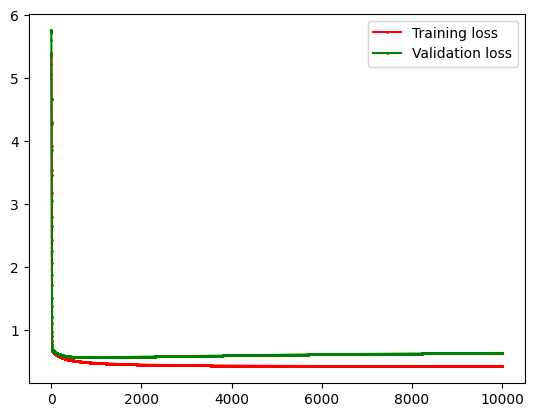

50. Training loss: 0.6571098767748111, Val loss:0.6697244267768969
100. Training loss: 0.6233246012236595, Val loss:0.643999865252734
150. Training loss: 0.5988483414837363, Val loss:0.6260046211970154
200. Training loss: 0.580503081098561, Val loss:0.6130584747744167
250. Training loss: 0.5663340514385814, Val loss:0.6035153895899893
300. Training loss: 0.555109610778399, Val loss:0.5963362172188005
350. Training loss: 0.5460282664733441, Val loss:0.5908438177965458
400. Training loss: 0.5385508819400877, Val loss:0.5865832541498985
450. Training loss: 0.5323033478328499, Val loss:0.5832403037115937
500. Training loss: 0.5270186638253865, Val loss:0.5805925757006578
550. Training loss: 0.5225014437416007, Val loss:0.5784792861358807
600. Training loss: 0.5186055098416564, Val loss:0.5767820163311911
650. Training loss: 0.5152193449448941, Val loss:0.5754121279039557
700. Training loss: 0.5122563954812427, Val loss:0.5743023265172252
750. Training loss: 0.5096484503192897, Val loss:0.5

4350. Training loss: 0.48401796480889586, Val loss:0.5716459691390839
4400. Training loss: 0.4840052601925854, Val loss:0.5716582990055022
4450. Training loss: 0.4839932466511241, Val loss:0.5716701564843095
4500. Training loss: 0.4839818846115226, Val loss:0.5716815587652101
4550. Training loss: 0.4839711369082522, Val loss:0.5716925225007671
4600. Training loss: 0.48396096862591115, Val loss:0.5717030638136811
4650. Training loss: 0.48395134695304853, Val loss:0.5717131983051931
4700. Training loss: 0.4839422410462847, Val loss:0.5717229410644249
4750. Training loss: 0.4839336219039359, Val loss:0.5717323066784833
4800. Training loss: 0.4839254622484186, Val loss:0.5717413092431847
4850. Training loss: 0.48391773641676833, Val loss:0.5717499623742651
4900. Training loss: 0.4839104202586658, Val loss:0.5717582792189647
4950. Training loss: 0.4839034910414061, Val loss:0.5717662724678928
5000. Training loss: 0.4838969273613019, Val loss:0.5717739543670732
5050. Training loss: 0.4838907

8300. Training loss: 0.4837786050361588, Val loss:0.5719481728466589
8350. Training loss: 0.48377838166913967, Val loss:0.5719486864769484
8400. Training loss: 0.48377816862783557, Val loss:0.5719491796783467
8450. Training loss: 0.4837779654183521, Val loss:0.5719496532640254
8500. Training loss: 0.48377777157121316, Val loss:0.5719501080148736
8550. Training loss: 0.48377758664011505, Val loss:0.5719505446807682
8600. Training loss: 0.4837774102007446, Val loss:0.5719509639817998
8650. Training loss: 0.48377724184966087, Val loss:0.5719513666094463
8700. Training loss: 0.4837770812032347, Val loss:0.5719517532277041
8750. Training loss: 0.4837769278966446, Val loss:0.5719521244741733
8800. Training loss: 0.48377678158292364, Val loss:0.5719524809611014
8850. Training loss: 0.48377664193205894, Val loss:0.5719528232763852
8900. Training loss: 0.48377650863013455, Val loss:0.5719531519845339
8950. Training loss: 0.4837763813785221, Val loss:0.5719534676275959
9000. Training loss: 0.483

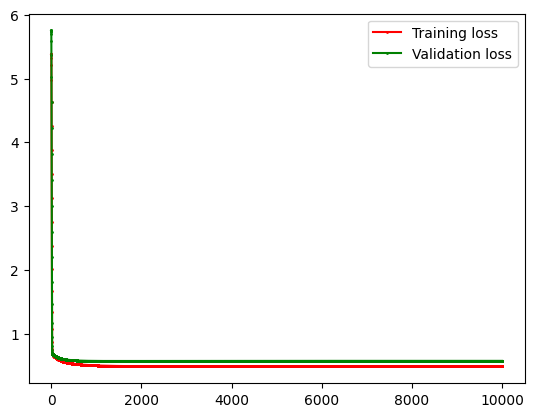

50. Training loss: 0.6750694290943433, Val loss:0.6840309642470094
100. Training loss: 0.6747548127534179, Val loss:0.6839309748933531
150. Training loss: 0.6747488372001222, Val loss:0.6839298599003173
200. Training loss: 0.6747487203171995, Val loss:0.6839298551190556
250. Training loss: 0.6747487180286232, Val loss:0.6839298554515596
300. Training loss: 0.6747487179838312, Val loss:0.6839298554687433
350. Training loss: 0.6747487179829557, Val loss:0.6839298554693461
400. Training loss: 0.6747487179829386, Val loss:0.6839298554693646
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss: 0.6747487179829382, Val loss:0

2450. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
2500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
2550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
2600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
2650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
2700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
2750. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
2800. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
2850. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
2900. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
2950. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3000. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3050. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3100. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
3150. Training loss: 0.67474871798

5800. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
5850. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
5900. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
5950. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6000. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6050. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6100. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6150. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6200. Training loss: 0.6747487179829382, Val loss:0.6839298554693651


6250. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6300. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6350. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6400. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6450. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6750. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6800. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6850. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6900. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
6950. Training loss: 0.67474871798

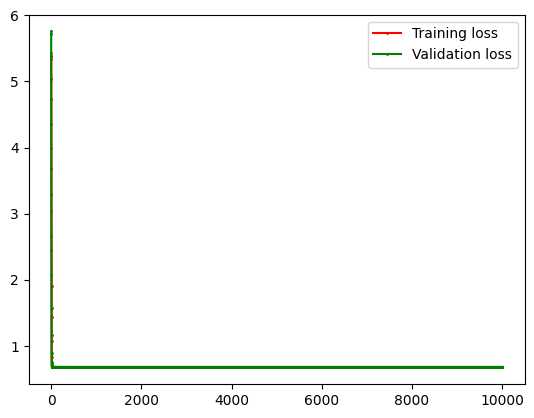

L2 Norms of weight vectors:
  No Reg (λ=0): ||W||₂ = 9.1868
  L2 (λ=0.01): ||W||₂ = 8.9686
  L2 (λ=1): ||W||₂ = 3.6437
  L2 (λ=100): ||W||₂ = 0.1428


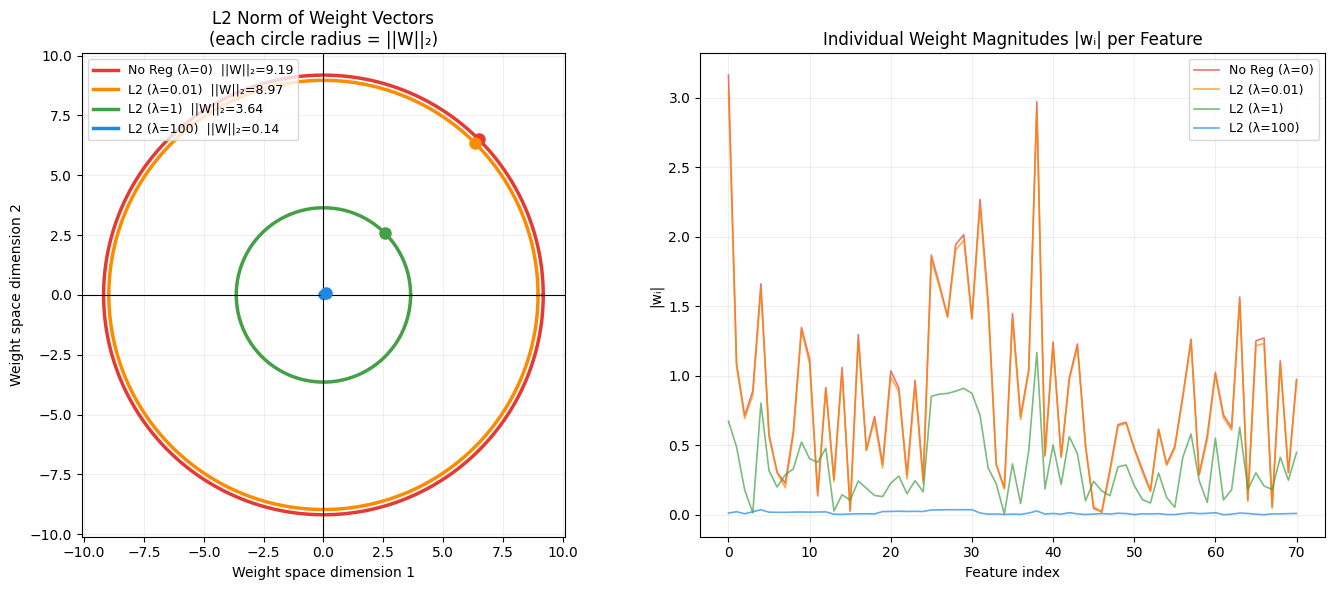

Saved: Chart/Q5_L2_geometric_interpretation.png


In [12]:
# Q5: Geometric Interpretation — L2 Norm of Weights under Different Lambda
# Visualize how the L2 constraint shrinks the weight vector toward the origin

import matplotlib.pyplot as plt
import numpy as np

# --- Re-train all 4 settings and collect the weight vectors ---
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

settings = [
    ('No Reg (λ=0)',       '', 0.0),
    ('L2 (λ=0.01)',      'l2', 0.01),
    ('L2 (λ=1)',         'l2', 1.0),
    ('L2 (λ=100)',       'l2', 100.0),
]

weight_vectors = []
weight_norms = []
labels_list = []

for label, reg_type, reg_lambda in settings:
    np.random.seed(seed)
    model = LinearModel(dim=X_train.shape[1], is_reg=False,
                        loss_fn=logloss, act_fn=sigmoid, grad_fn=logloss_sigmoid_grad)
    model.fit(X_train, y_train, lr=0.1, n_iteration=10000, val_ratio=0.2,
              reg_type=reg_type, reg_lambda=reg_lambda)
    plt.close('all')

    weight_vectors.append(model.W.copy())
    weight_norms.append(np.sqrt(np.sum(model.W ** 2)))  # L2 norm
    labels_list.append(label)

print("L2 Norms of weight vectors:")
for lbl, norm in zip(labels_list, weight_norms):
    print(f"  {lbl}: ||W||₂ = {norm:.4f}")

# ============================================================
# Plot 1: L2 Norm circles — each experiment's weight norm shown as a circle
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#E53935', '#FB8C00', '#43A047', '#1E88E5']
theta = np.linspace(0, 2 * np.pi, 200)

for i, (lbl, norm) in enumerate(zip(labels_list, weight_norms)):
    x_circle = norm * np.cos(theta)
    y_circle = norm * np.sin(theta)
    ax1.plot(x_circle, y_circle, color=colors[i], linewidth=2.5, label=f'{lbl}  ||W||₂={norm:.2f}')
    # Mark a point on the circle (at 45°) to show the "tip" of the weight vector
    ax1.plot(norm * np.cos(np.pi/4), norm * np.sin(np.pi/4), 'o',
             color=colors[i], markersize=8, zorder=5)

ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_aspect('equal')
ax1.set_title('L2 Norm of Weight Vectors\n(each circle radius = ||W||₂)', fontsize=12)
ax1.set_xlabel('Weight space dimension 1', fontsize=10)
ax1.set_ylabel('Weight space dimension 2', fontsize=10)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.2)

# ============================================================
# Plot 2: Weight distribution comparison — show individual weight magnitudes
# ============================================================
n_features = len(weight_vectors[0])
x_pos = np.arange(n_features)

for i, (lbl, W) in enumerate(zip(labels_list, weight_vectors)):
    ax2.plot(x_pos, np.abs(W), color=colors[i], alpha=0.7, linewidth=1.2, label=lbl)

ax2.set_title('Individual Weight Magnitudes |wᵢ| per Feature', fontsize=12)
ax2.set_xlabel('Feature index', fontsize=10)
ax2.set_ylabel('|wᵢ|', fontsize=10)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
fig.savefig('Chart/Q5_L2_geometric_interpretation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Chart/Q5_L2_geometric_interpretation.png")

## Assignment 2 - Question 1: K-fold Cross-Validation

### Q1(a): 5-Fold Cross-Validation — 4×4 Hyperparameter Grid

L2 regularization with:
- Learning rates: {0.005, 0.01, 0.1, 0.5}
- Regularization parameters: {1.0, 2.0, 4.0, 8.0}

In [9]:
# Q1(a): 5-Fold Cross-Validation with L2 Regularization
from sklearn.model_selection import KFold, cross_val_score
from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid
import pandas as pd

learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

cv = KFold(n_splits=5, shuffle=True, random_state=40)

# Store results in a 4x4 grid
results = np.zeros((len(reg_lambdas), len(learning_rates)))

for i, reg_lambda in enumerate(reg_lambdas):
    for j, lr in enumerate(learning_rates):
        model = LinearModel(
            is_reg=False,
            loss_fn=logloss,
            grad_fn=logloss_sigmoid_grad,
            act_fn=sigmoid,
            lr=lr,
            reg_type='l2',
            reg_lambda=reg_lambda,
            n_iteration=10000,
            val_ratio=0.2,
            random_state=seed,
            verbose=False,
            plot_curve=False
        )
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
        avg_acc = scores.mean()
        results[i, j] = avg_acc
        print(f"lr={lr}, reg_lambda={reg_lambda}: avg_accuracy={avg_acc:.4f} (folds: {scores})")

# Display as 4x4 table
results_df = pd.DataFrame(
    results,
    index=[f'λ={lam}' for lam in reg_lambdas],
    columns=[f'lr={lr}' for lr in learning_rates]
)
print("\n=== Q1(a): 5-Fold CV Average Accuracy ===")
print(results_df.to_string())

lr=0.005, reg_lambda=1.0: avg_accuracy=0.7171 (folds: [0.7        0.75714286 0.72857143 0.64285714 0.75714286])
lr=0.01, reg_lambda=1.0: avg_accuracy=0.7229 (folds: [0.7        0.78571429 0.72857143 0.61428571 0.78571429])
lr=0.1, reg_lambda=1.0: avg_accuracy=0.7229 (folds: [0.71428571 0.74285714 0.71428571 0.67142857 0.77142857])
lr=0.5, reg_lambda=1.0: avg_accuracy=0.7229 (folds: [0.71428571 0.74285714 0.71428571 0.67142857 0.77142857])
lr=0.005, reg_lambda=2.0: avg_accuracy=0.7200 (folds: [0.7        0.75714286 0.71428571 0.64285714 0.78571429])
lr=0.01, reg_lambda=2.0: avg_accuracy=0.7286 (folds: [0.71428571 0.78571429 0.72857143 0.62857143 0.78571429])
lr=0.1, reg_lambda=2.0: avg_accuracy=0.7257 (folds: [0.72857143 0.77142857 0.7        0.64285714 0.78571429])
lr=0.5, reg_lambda=2.0: avg_accuracy=0.6914 (folds: [0.74285714 0.77142857 0.61428571 0.64285714 0.68571429])
lr=0.005, reg_lambda=4.0: avg_accuracy=0.7257 (folds: [0.72857143 0.74285714 0.71428571 0.67142857 0.77142857])
lr

### Q1(b): Top 2 Hyperparameter Settings — Test Set Evaluation

Select the two best combinations from Q1(a) and evaluate on the held-out test set.


Top 1: lr=0.01, reg_lambda=2.0 (CV avg accuracy=0.7286)
Top 1: lr=0.01, λ=2.0
Accuracy  : 0.7600
Precision : 0.7381
Recall    : 0.8158
F1-score  : 0.7750


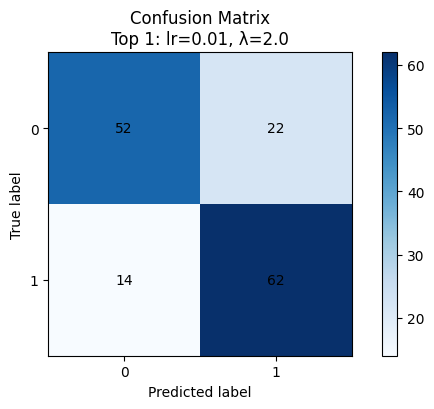


Top 2: lr=0.01, reg_lambda=4.0 (CV avg accuracy=0.7257)
Top 2: lr=0.01, λ=4.0
Accuracy  : 0.7400
Precision : 0.7176
Recall    : 0.8026
F1-score  : 0.7578


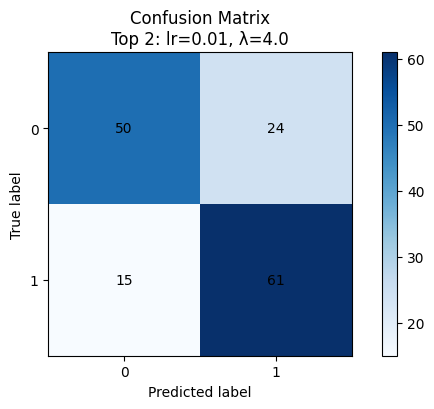

In [10]:
# Q1(b): Train with top 2 hyperparameter combos and evaluate on test set

# Find top 2 combinations from the results grid
flat_indices = np.argsort(results.ravel())[::-1][:2]
top2 = [(flat_indices[k] // len(learning_rates), flat_indices[k] % len(learning_rates)) for k in range(2)]

for rank, (i, j) in enumerate(top2, 1):
    lr = learning_rates[j]
    reg_lambda = reg_lambdas[i]
    avg_acc = results[i, j]
    
    print(f"\n{'='*60}")
    print(f"Top {rank}: lr={lr}, reg_lambda={reg_lambda} (CV avg accuracy={avg_acc:.4f})")
    print(f"{'='*60}")
    
    # Train on full training set
    np.random.seed(seed)
    model = LinearModel(
        is_reg=False,
        loss_fn=logloss,
        grad_fn=logloss_sigmoid_grad,
        act_fn=sigmoid,
        lr=lr,
        reg_type='l2',
        reg_lambda=reg_lambda,
        n_iteration=10000,
        val_ratio=0.2,
        random_state=seed,
        verbose=False,
        plot_curve=False
    )
    model.fit(X_train, y_train)
    
    # Evaluate on test set
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(
        y_test, y_pred,
        title=f'Top {rank}: lr={lr}, λ={reg_lambda}',
        save_path=f'Chart/Q1b_top{rank}_lr{lr}_lambda{reg_lambda}.png'
    )

### Q1(b) Extension: Tied Top-2 Configurations

The Top-2 CV accuracy (0.7257) is actually a **4-way tie** across:
- `lr=0.005, λ=4.0`
- `lr=0.01,  λ=4.0` (already shown above as "Top 2")
- `lr=0.1,   λ=4.0`
- `lr=0.1,   λ=2.0`

Training each tied configuration on the full training set and evaluating on the held-out test set to check whether `λ=4` provides a consistent performance boost.


Tied config: lr=0.005, reg_lambda=4.0
Tied: lr=0.005, λ=4.0
Accuracy  : 0.7533
Precision : 0.7241
Recall    : 0.8289
F1-score  : 0.7730


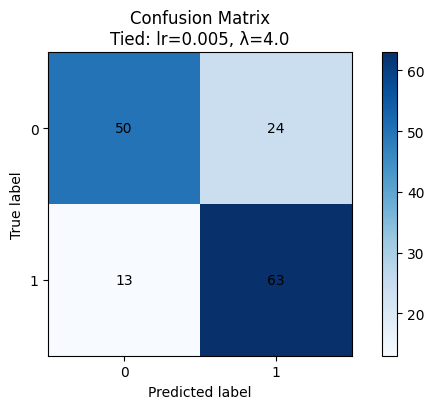


Tied config: lr=0.01, reg_lambda=4.0
Tied: lr=0.01, λ=4.0
Accuracy  : 0.7400
Precision : 0.7176
Recall    : 0.8026
F1-score  : 0.7578


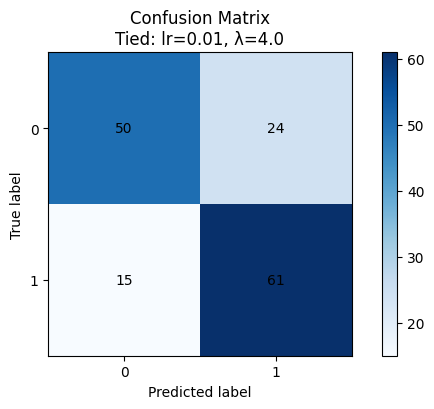


Tied config: lr=0.1, reg_lambda=4.0
Tied: lr=0.1, λ=4.0
Accuracy  : 0.7400
Precision : 0.7176
Recall    : 0.8026
F1-score  : 0.7578


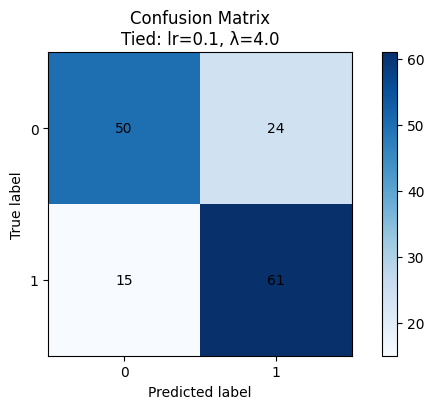


Tied config: lr=0.1, reg_lambda=2.0
Tied: lr=0.1, λ=2.0
Accuracy  : 0.7533
Precision : 0.7294
Recall    : 0.8158
F1-score  : 0.7702


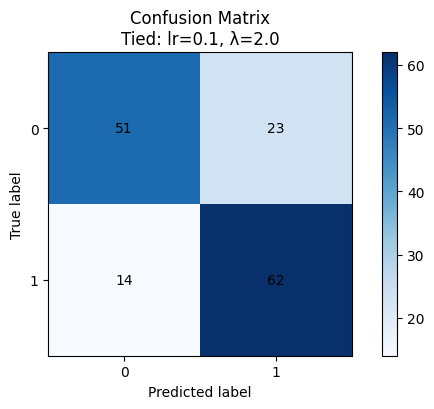

In [11]:
# Q1(b) Extension: Evaluate all tied top-2 configurations (CV avg = 0.7257)
tied_configs = [
    (0.005, 4.0),
    (0.01,  4.0),
    (0.1,   4.0),
    (0.1,   2.0),
]

for lr, reg_lambda in tied_configs:
    print(f"\n{'='*60}")
    print(f"Tied config: lr={lr}, reg_lambda={reg_lambda}")
    print(f"{'='*60}")

    np.random.seed(seed)
    model = LinearModel(
        is_reg=False,
        loss_fn=logloss,
        grad_fn=logloss_sigmoid_grad,
        act_fn=sigmoid,
        lr=lr,
        reg_type='l2',
        reg_lambda=reg_lambda,
        n_iteration=10000,
        val_ratio=0.2,
        random_state=seed,
        verbose=False,
        plot_curve=False
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    evaluate_binary_classifier(
        y_test, y_pred,
        title=f'Tied: lr={lr}, λ={reg_lambda}',
        save_path=f'Chart/Q1b_tied_lr{lr}_lambda{reg_lambda}.png'
    )